### Importación de datos



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



Ventas de la Tienda 1: $1,038,375,700
Ventas de la Tienda 2: $1,116,343,500
Ventas de la Tienda 3: $1,098,019,600
Ventas de la Tienda 4: $1,038,375,700

Ventas conjuntas de las 4 tiendas: $4,291,114,500

Grafico comparativo de recaudacion por ventas totales:


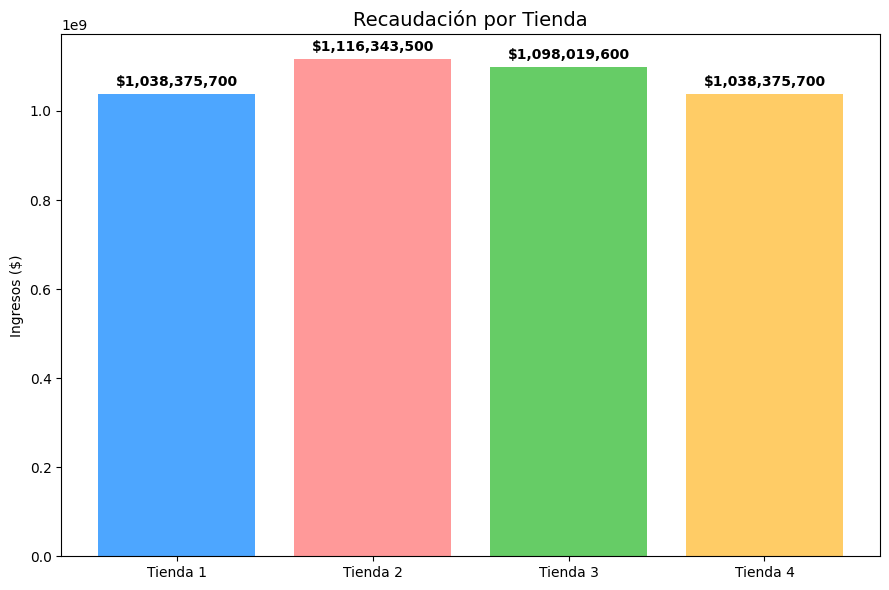

In [18]:
lista_tiendas = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ingresos = []

for i, df in enumerate(lista_tiendas):
    df["Precio"] = df["Precio"].round(0).astype(int)
    suma = df["Precio"].sum()
    ingresos.append(suma)

    print(f"Ventas de la {nombres_tiendas[i]}: ${suma:,}")

ventas_totales = sum(ingresos)
print(f"\nVentas conjuntas de las {len(lista_tiendas)} tiendas: ${ventas_totales:,}")

print("\nGrafico comparativo de recaudacion por ventas totales:")
colores = ['#4da6ff', '#ff9999', '#66cc66', '#ffcc66']

plt.figure(figsize=(9, 6))
barras = plt.bar(nombres_tiendas, ingresos, color=colores)

for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + (yval * 0.01),
             f"${int(yval):,}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Recaudación por Tienda', fontsize=14)
plt.ylabel('Ingresos ($)')
plt.tight_layout()
plt.show()

# 2. Ventas por categoría


--- Resumen Tienda 1 ---
 Categoría del Producto  Cantidad    Recaudado
                Muebles       480 $192,528,900
           Electrónicos       451 $409,476,100
               Juguetes       338  $20,262,200
   Deportes y diversión       277  $33,350,100
      Electrodomésticos       254 $283,260,200
Artículos para el hogar       201  $15,074,500
                 Libros       187   $9,321,300
 Instrumentos musicales       170  $75,102,400
Nota: En Tienda 1, Electrónicos recauda más, pero Muebles es más popular.

--- Resumen Tienda 2 ---
 Categoría del Producto  Cantidad    Recaudado
                Muebles       442 $176,426,300
           Electrónicos       422 $410,831,100
               Juguetes       313  $15,945,400
      Electrodomésticos       305 $348,567,800
   Deportes y diversión       275  $34,744,500
 Instrumentos musicales       224 $104,990,300
                 Libros       197  $10,091,200
Artículos para el hogar       181  $14,746,900
Nota: En Tienda 2, Electróni

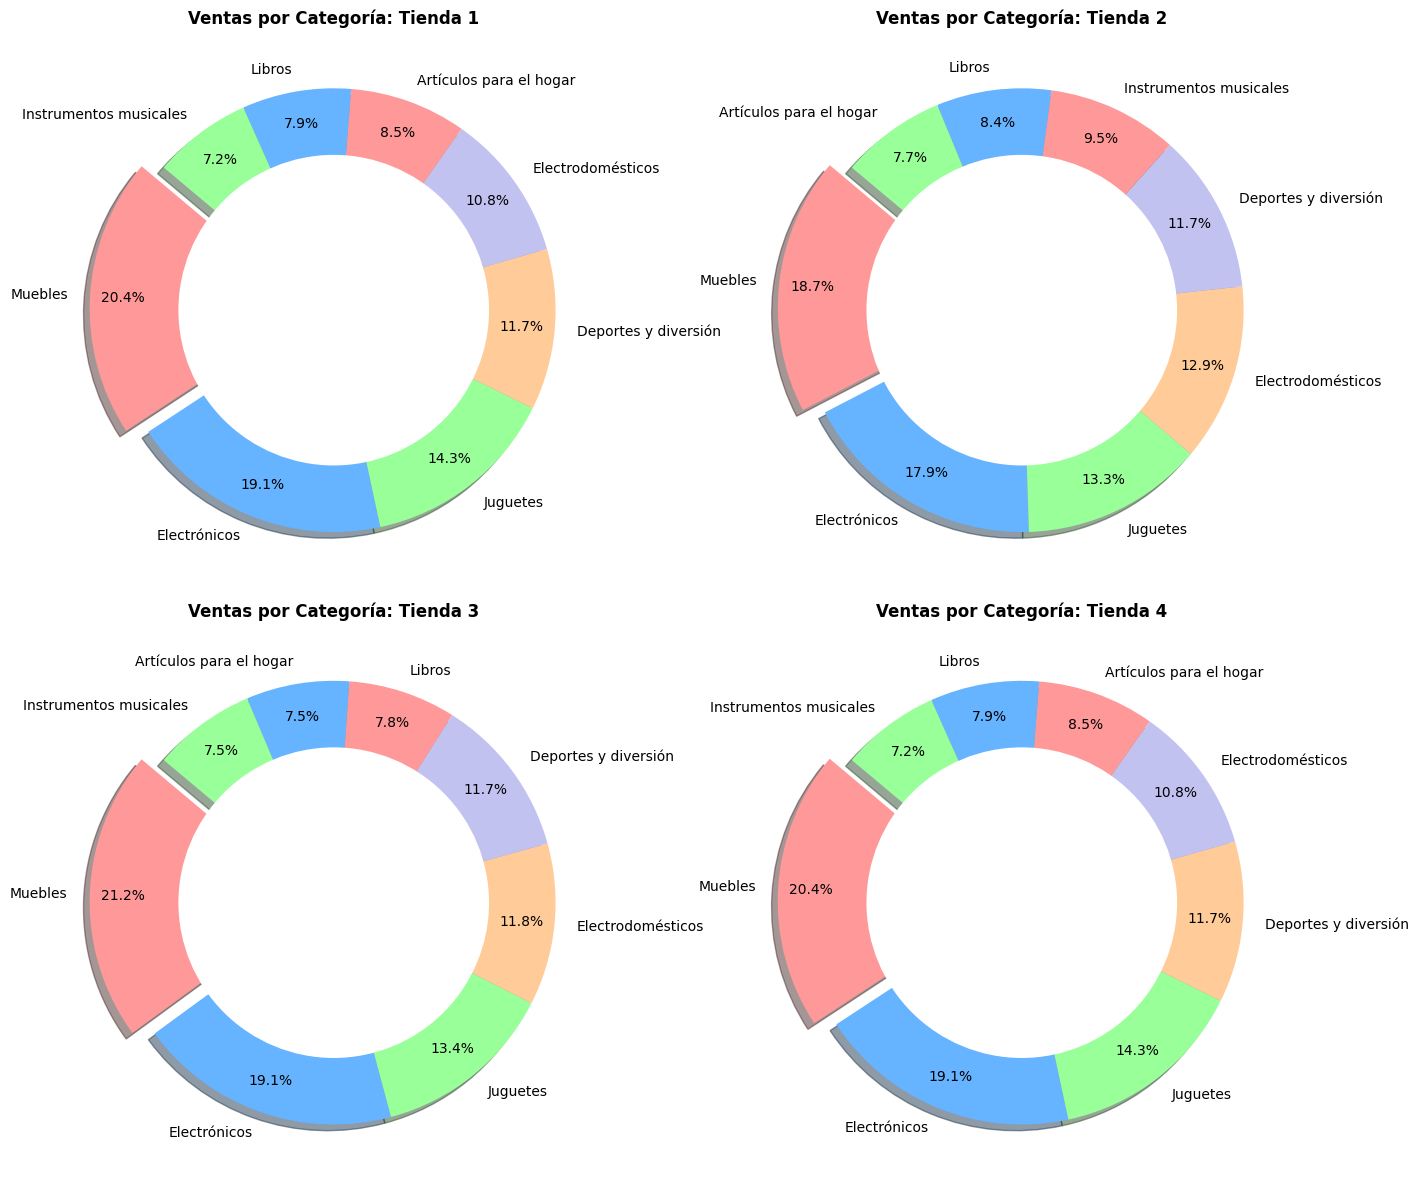


Conclusión: Se observa que, aunque 'Electrónicos' suele liderar la recaudación, categorías como 'Accesorios' o 'Ropa' pueden superarla en volumen de unidades vendidas.


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colores = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

for i, (nombre_tienda, tienda) in enumerate(zip(tienda_nombres, tiendas)):
    ventas_cat = tienda.groupby('Categoría del Producto').agg(
        Cantidad=('Precio', 'count'),
        Recaudado=('Precio', 'sum')
    ).reset_index().sort_values(by='Cantidad', ascending=False)
    print(f"\n--- Resumen {nombre_tienda} ---")
    resumen_print = ventas_cat.copy()
    resumen_print['Recaudado'] = resumen_print['Recaudado'].apply(lambda x: f"${x:,.0f}")
    print(resumen_print.to_string(index=False))
    top_volumen = ventas_cat.iloc[0]['Categoría del Producto']
    top_recaudacion = ventas_cat.sort_values(by='Recaudado', ascending=False).iloc[0]['Categoría del Producto']

    if top_volumen != top_recaudacion:
        print(f"Nota: En {nombre_tienda}, {top_recaudacion} recauda más, pero {top_volumen} es más popular.")
    ax = axes[i]
    explode = [0.1 if j == 0 else 0 for j in range(len(ventas_cat))]

    ax.pie(
        ventas_cat['Cantidad'],
        labels=ventas_cat['Categoría del Producto'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colores,
        explode=explode,
        shadow=True,
        pctdistance=0.85
    )
    centro_circulo = plt.Circle((0,0), 0.70, fc='white')
    ax.add_artist(centro_circulo)

    ax.set_title(f'Ventas por Categoría: {nombre_tienda}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nConclusión: Se observa que, aunque 'Electrónicos' suele liderar la recaudación, categorías como 'Accesorios' o 'Ropa' pueden superarla en volumen de unidades vendidas.")

# 3. Calificación promedio de la tienda


In [15]:
print(f"Calificación promedio de las tiendas:")
tiendas = [tienda, tienda2, tienda3, tienda4]
for i, t in enumerate(tiendas, 1):
    promedio = round(t["Calificación"].mean(), 2)
    print(f"tienda {i}: {promedio}")
todas_calificaciones = pd.concat([t["Calificación"] for t in tiendas])
promedio_global = round(todas_calificaciones.mean(), 2)

print(f"La satisfacción promedio real de todas las tiendas es {promedio_global}")

Calificación promedio de las tiendas:
tienda 1: 4.0
tienda 2: 4.04
tienda 3: 4.05
tienda 4: 4.0
La satisfacción promedio real de todas las tiendas es 4.02


# 4. Productos más y menos vendidos


 ANÁLISIS: TIENDA 1


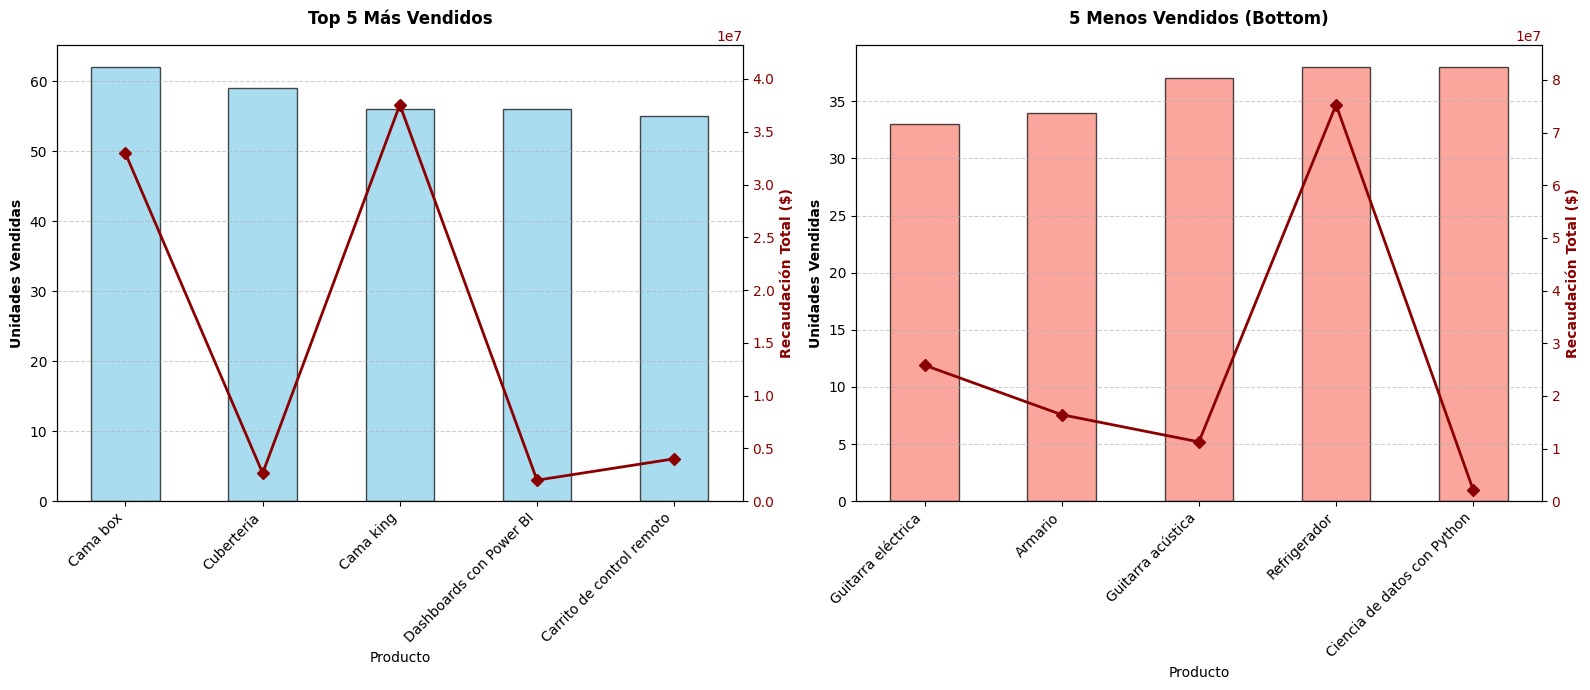


 ANÁLISIS: TIENDA 2


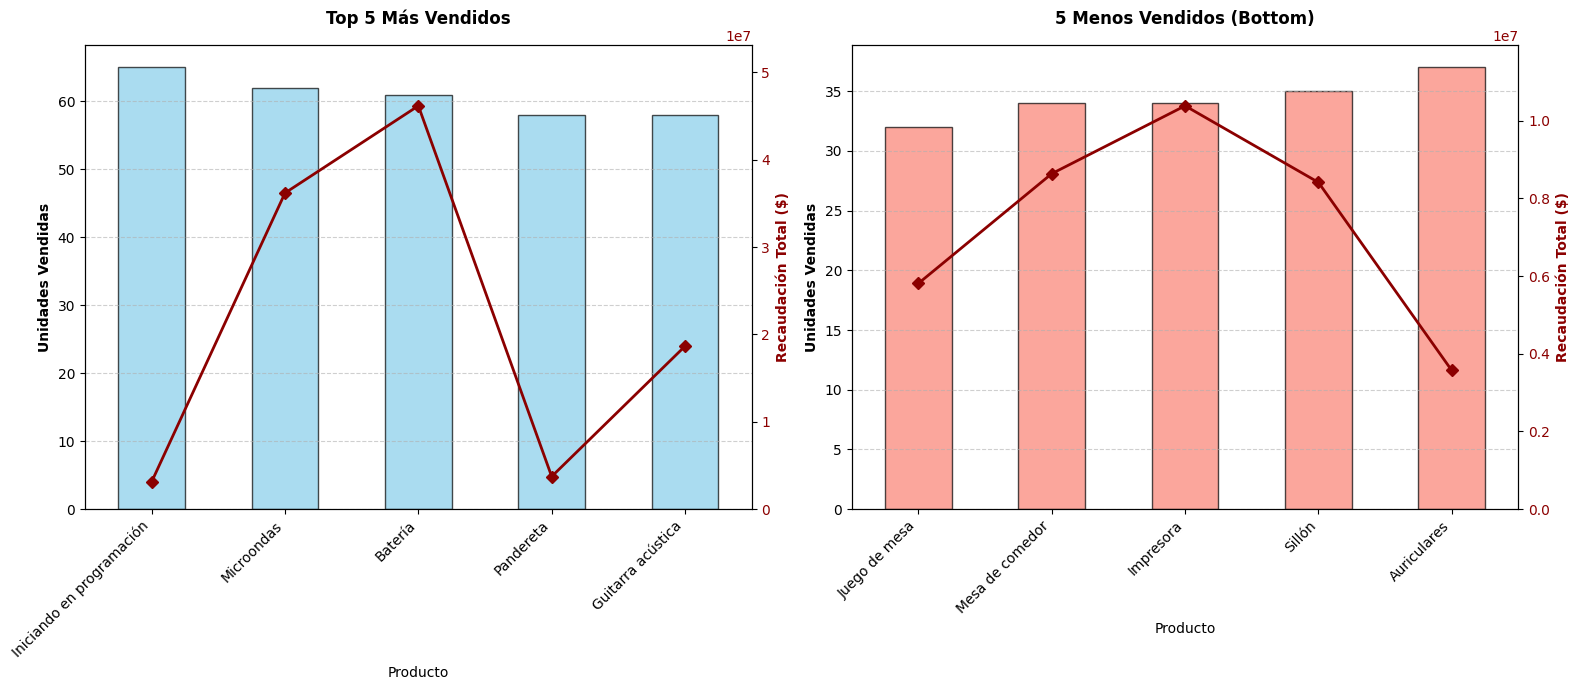


 ANÁLISIS: TIENDA 3


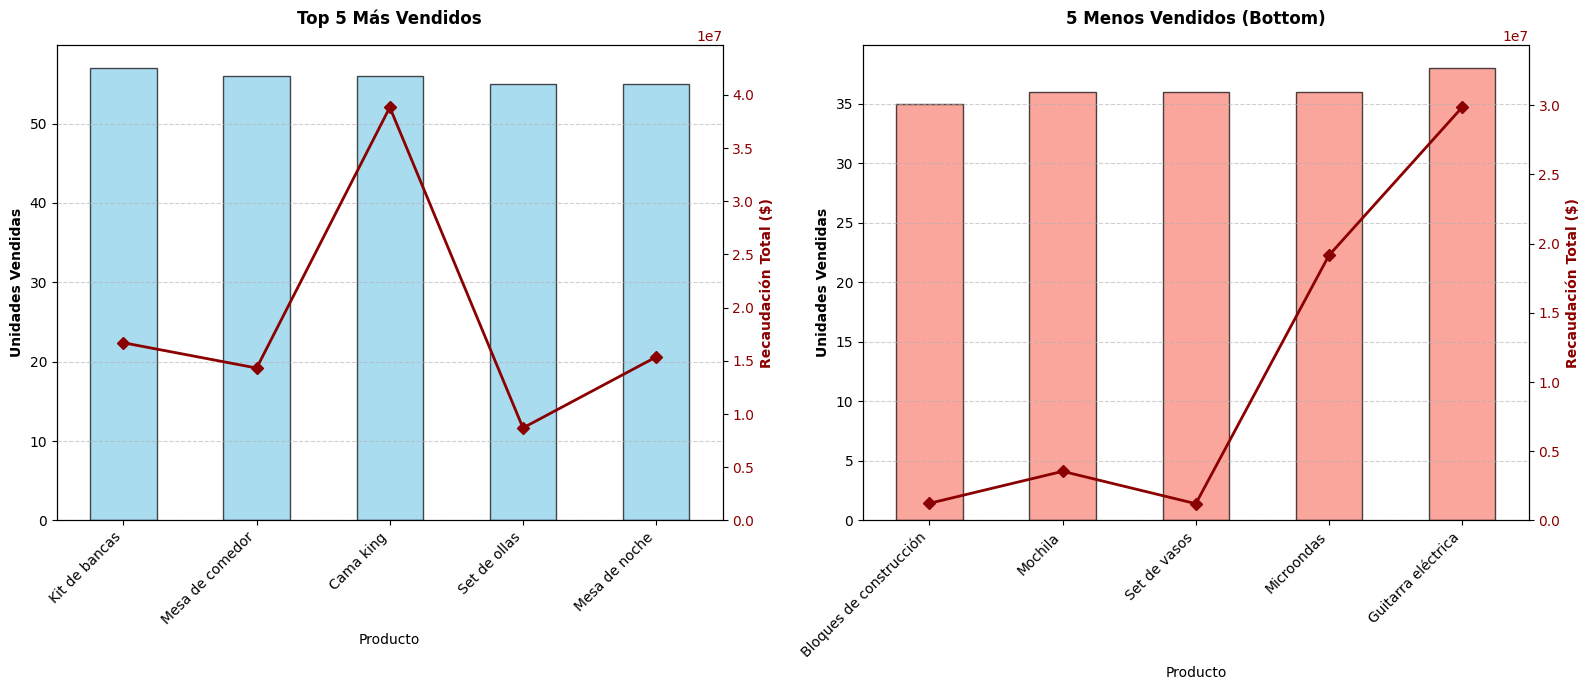


 ANÁLISIS: TIENDA 4


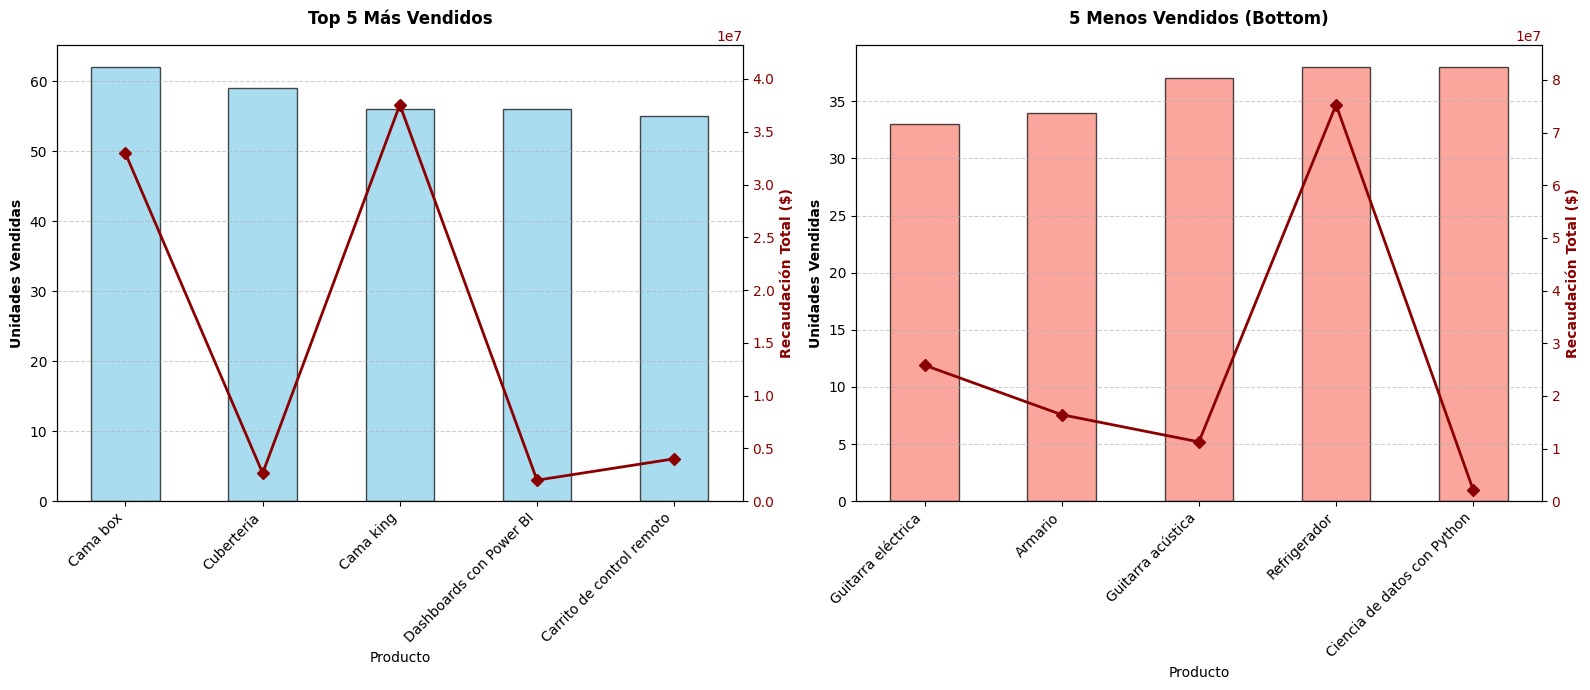

In [20]:
def analisisDEproductos(nombre_tienda, df):
    resumen = df.groupby("Producto").agg(
        CantidadVendida=('Precio', 'count'),
        RecaudacionTotal=('Precio', 'sum')
    ).sort_values("CantidadVendida", ascending=False)

    top_5 = resumen.head(5)
    bottom_5 = resumen.tail(5).sort_values("CantidadVendida")

    print(f"\n{'='*40}\n ANÁLISIS: {nombre_tienda.upper()}\n{'='*40}")
    fig, (ax_top, ax_bot) = plt.subplots(1, 2, figsize=(16, 7))

    def configurar_grafico(ax_principal, data, titulo, color_bar):
        data["CantidadVendida"].plot(kind="bar", color=color_bar, alpha=0.7, edgecolor='black', ax=ax_principal)
        ax_principal.set_title(titulo, fontsize=12, fontweight='bold', pad=15)
        ax_principal.set_ylabel("Unidades Vendidas", fontweight='bold')
        ax_principal.set_xticklabels(data.index, rotation=45, ha='right')
        ax_principal.grid(axis='y', linestyle='--', alpha=0.6)
        ax_secundario = ax_principal.twinx()
        ax_secundario.plot(data.index, data["RecaudacionTotal"], color='darkred', marker='D',
                           markersize=6, linewidth=2, label='Recaudación ($)')
        ax_secundario.set_ylabel("Recaudación Total ($)", color='darkred', fontweight='bold')
        ax_secundario.tick_params(axis='y', labelcolor='darkred')

        ax_secundario.set_ylim(0, data["RecaudacionTotal"].max() * 1.15)

    configurar_grafico(ax_top, top_5, f"Top 5 Más Vendidos", "skyblue")
    configurar_grafico(ax_bot, bottom_5, f"5 Menos Vendidos (Bottom)", "salmon")

    plt.tight_layout()
    plt.show()

diccionario_tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

for nombre, df_tienda in diccionario_tiendas.items():
    analisisDEproductos(nombre, df_tienda)

# 5. Envío promedio por tienda

Tienda          | Costo Promedio 
--------------------------------
Tienda 1        | $      23459.46
Tienda 2        | $      25216.24
Tienda 3        | $      24805.68
Tienda 4        | $      23459.46
--------------------------------
TOTAL GLOBAL    | $      24235.21



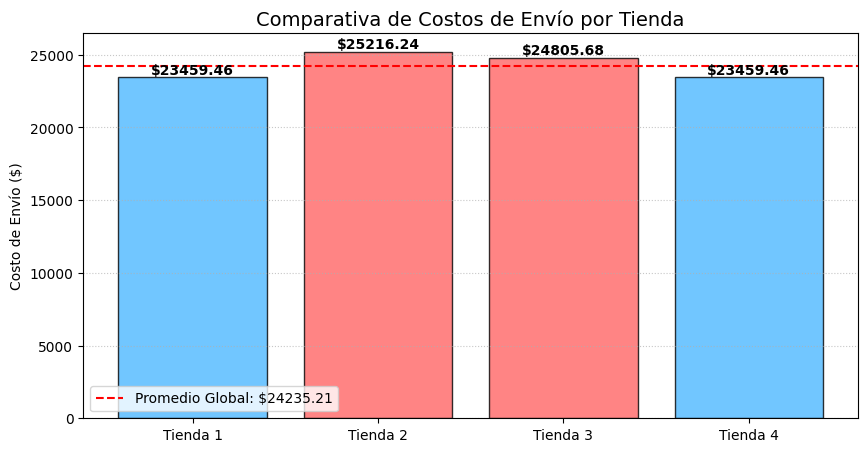

In [21]:
def analizar_costos_envio(dict_tiendas):
    nombres = []
    promedios = []

    print(f"{'Tienda':<15} | {'Costo Promedio':<15}")
    print("-" * 32)

    for nombre, df in dict_tiendas.items():
        promedio = df["Costo de envío"].mean()
        nombres.append(nombre)
        promedios.append(promedio)
        print(f"{nombre:<15} | ${promedio:>14.2f}")

    promedio_global = sum(promedios) / len(promedios)
    print("-" * 32)
    print(f"{'TOTAL GLOBAL':<15} | ${promedio_global:>14.2f}\n")

    plt.figure(figsize=(10, 5))
    colores = ['#4db8ff' if p <= promedio_global else '#ff6666' for p in promedios]

    barras = plt.bar(nombres, promedios, color=colores, edgecolor='black', alpha=0.8)

    plt.axhline(promedio_global, color='red', linestyle='--', label=f'Promedio Global: ${promedio_global:.2f}')

    for barra in barras:
        yval = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, yval + 0.1, f"${yval:.2f}",
                 ha='center', va='bottom', fontweight='bold')

    plt.title('Comparativa de Costos de Envío por Tienda', fontsize=14)
    plt.ylabel('Costo de Envío ($)')
    plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.show()

mis_tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

analizar_costos_envio(mis_tiendas)

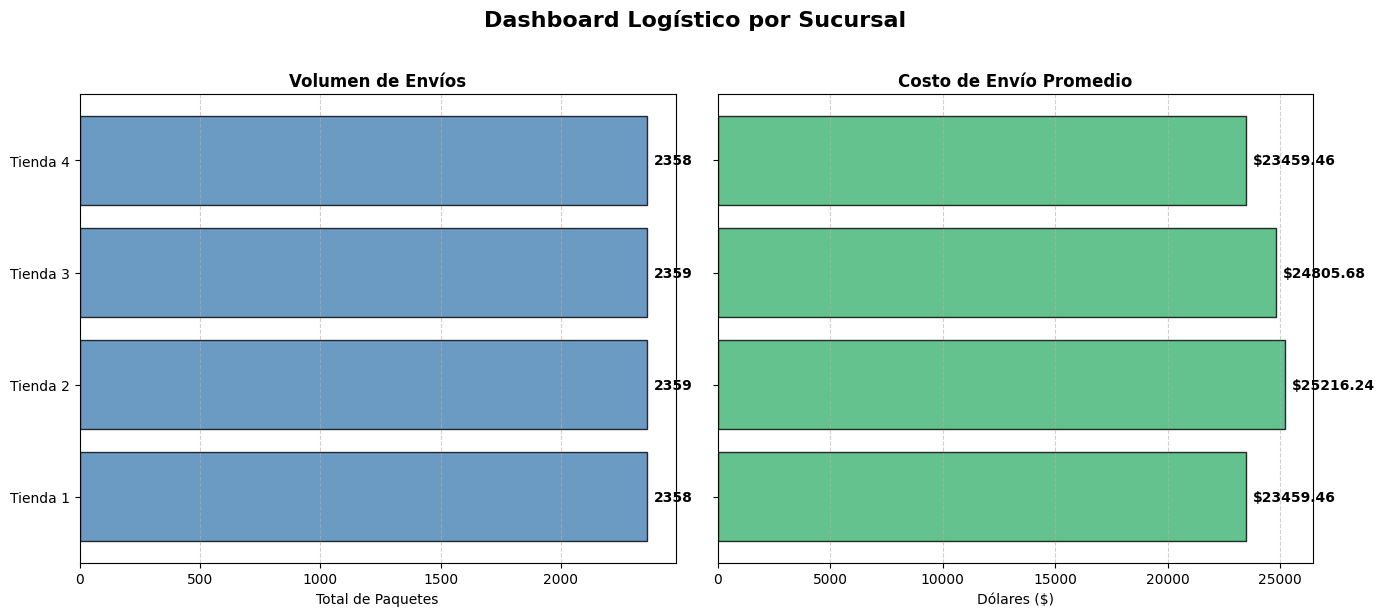

In [22]:
tiendas_dict = {"Tienda 1": tienda, "Tienda 2": tienda2, "Tienda 3": tienda3, "Tienda 4": tienda4}

nombres = list(tiendas_dict.keys())
cantidades = [len(df) for df in tiendas_dict.values()]
promedios = [df["Costo de envío"].mean() for df in tiendas_dict.values()]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

b1 = ax1.barh(nombres, cantidades, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_title("Volumen de Envíos", fontsize=12, fontweight='bold')
ax1.set_xlabel("Total de Paquetes")
ax1.grid(axis='x', linestyle='--', alpha=0.6)

b2 = ax2.barh(nombres, promedios, color='mediumseagreen', edgecolor='black', alpha=0.8)
ax2.set_title("Costo de Envío Promedio", fontsize=12, fontweight='bold')
ax2.set_xlabel("Dólares ($)")
ax2.grid(axis='x', linestyle='--', alpha=0.6)

ax1.bar_label(b1, padding=5, fontweight='bold')
ax2.bar_label(b2, fmt='$%.2f', padding=5, fontweight='bold')

plt.suptitle("Dashboard Logístico por Sucursal", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
""" Tras el análisis multidimensional, se propone la desinversión de la Tienda 4.
Aunque la Tienda 2 tiene un rendimiento medio, su potencial justifica mantenerla,
mientras que la Tienda 4 ha alcanzado su techo operativo con el retorno más bajo del grupo. """